# Task 2 — Exploratory Data Analysis: Titanic Dataset

Input: `titanic_cleaned.csv` from Task 1 (missing values handled, `HasCabin`/`FareOutlier` flags added,
duplicates confirmed absent). This notebook goes past basic cleaning into relationships, trends,
and interaction effects — building the picture that Task 3's model will lean on.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/titanic_cleaned.csv")
df.shape

(891, 13)

## 1. Feature engineering for analysis

A few derived fields make the relationships easier to see: family size, a title pulled from `Name`,
and an age bucket.

In [3]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

df["Title"] = df["Name"].str.extract(r",\s*([^.]*)\.")
title_map = {
    "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
    "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
    "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
    "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare",
}
df["Title"] = df["Title"].replace(title_map)
df["Title"] = df["Title"].where(df["Title"].isin(["Mr", "Mrs", "Miss", "Master", "Rare"]), "Rare")

df["AgeGroup"] = pd.cut(df["Age"], bins=[0, 12, 18, 35, 60, 100],
                         labels=["Child", "Teen", "Adult", "MiddleAge", "Senior"])

df[["FamilySize", "IsAlone", "Title", "AgeGroup"]].head()

,FamilySize,IsAlone,Title,AgeGroup
0,2,0,Mr,Adult
1,2,0,Mrs,MiddleAge
2,1,1,Miss,Adult
3,2,0,Mrs,Adult
4,1,1,Mr,Adult


## 2. Univariate patterns (quick recap, deeper cut on categorical distributions)

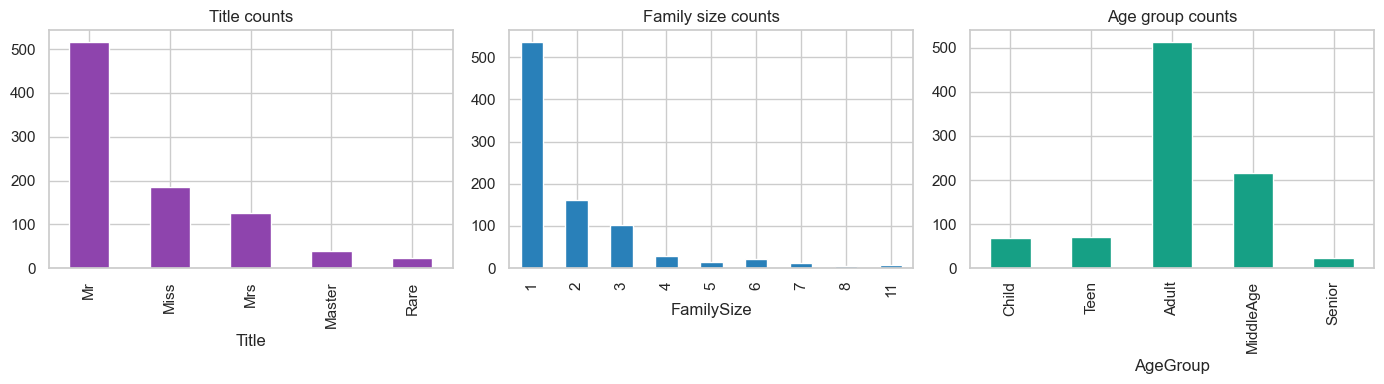

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
df["Title"].value_counts().plot(kind="bar", ax=axes[0], color="#8e44ad")
axes[0].set_title("Title counts")
df["FamilySize"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#2980b9")
axes[1].set_title("Family size counts")
df["AgeGroup"].value_counts().reindex(["Child","Teen","Adult","MiddleAge","Senior"]).plot(kind="bar", ax=axes[2], color="#16a085")
axes[2].set_title("Age group counts")
plt.tight_layout()
plt.savefig("../images/univariate_categoricals.png", dpi=120)
plt.show()

## 3. Survival vs. key variables

Bivariate cuts against the target across the variables most likely to matter.

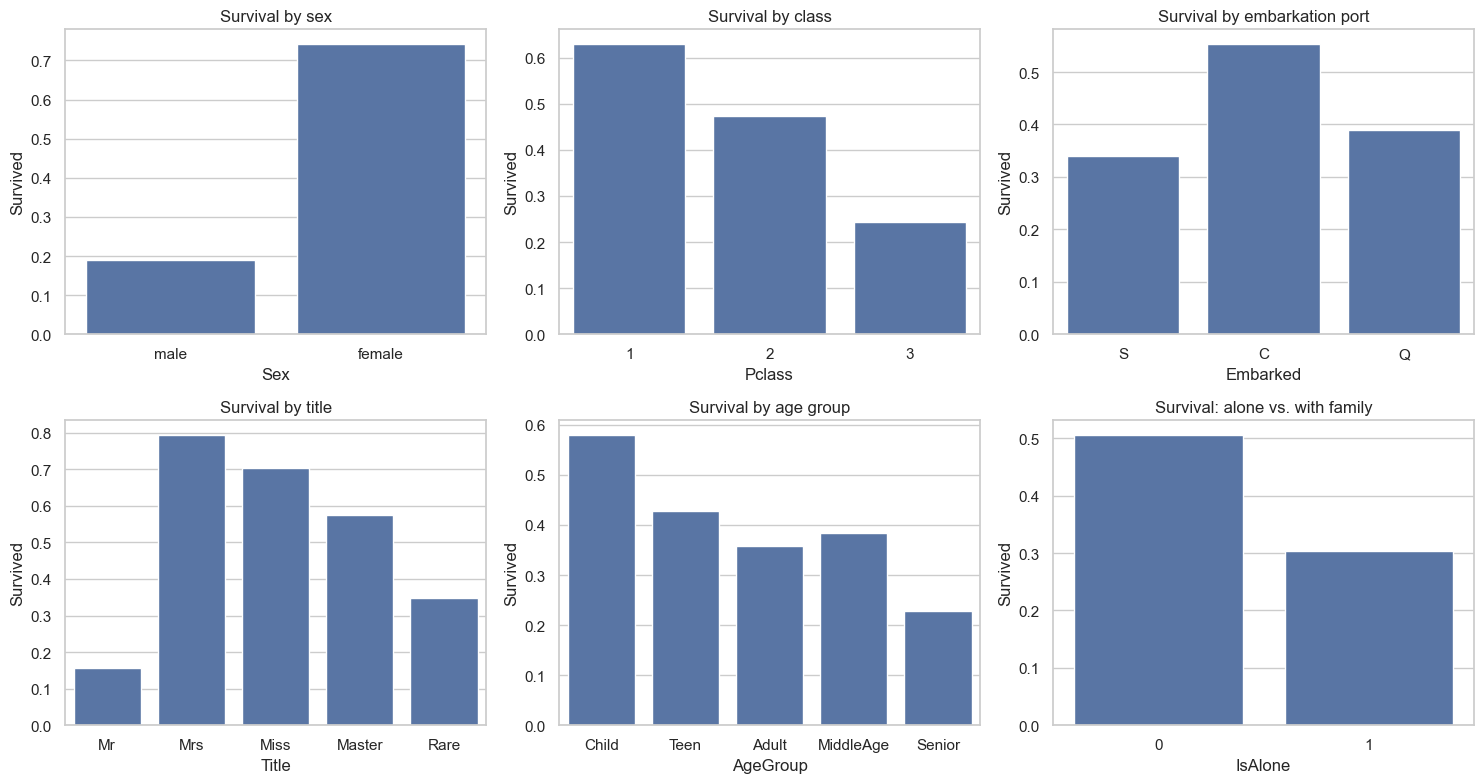

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0,0], errorbar=None)
axes[0,0].set_title("Survival by sex")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[0,1], errorbar=None)
axes[0,1].set_title("Survival by class")

sns.barplot(data=df, x="Embarked", y="Survived", ax=axes[0,2], errorbar=None)
axes[0,2].set_title("Survival by embarkation port")

sns.barplot(data=df, x="Title", y="Survived", ax=axes[1,0], errorbar=None,
            order=["Mr","Mrs","Miss","Master","Rare"])
axes[1,0].set_title("Survival by title")

sns.barplot(data=df, x="AgeGroup", y="Survived", ax=axes[1,1], errorbar=None,
            order=["Child","Teen","Adult","MiddleAge","Senior"])
axes[1,1].set_title("Survival by age group")

sns.barplot(data=df, x="IsAlone", y="Survived", ax=axes[1,2], errorbar=None)
axes[1,2].set_title("Survival: alone vs. with family")

plt.tight_layout()
plt.savefig("../images/survival_bivariate.png", dpi=120)
plt.show()

In [7]:
print("Survival rate by sex:\n", (df.groupby("Sex")["Survived"].mean()*100).round(1), "\n")
print("Survival rate by Pclass:\n", (df.groupby("Pclass")["Survived"].mean()*100).round(1), "\n")
print("Survival rate by Title:\n", (df.groupby("Title")["Survived"].mean()*100).round(1), "\n")
print("Survival rate by FamilySize:\n", (df.groupby("FamilySize")["Survived"].mean()*100).round(1))

Survival rate by sex:
 Sex
female    74.2
male      18.9
Name: Survived, dtype: float64 

Survival rate by Pclass:
 Pclass
1    63.0
2    47.3
3    24.2
Name: Survived, dtype: float64 

Survival rate by Title:
 Title
Master    57.5
Miss      70.3
Mr        15.7
Mrs       79.4
Rare      34.8
Name: Survived, dtype: float64 

Survival rate by FamilySize:
 FamilySize
1     30.4
2     55.3
3     57.8
4     72.4
5     20.0
6     13.6
7     33.3
8      0.0
11     0.0
Name: Survived, dtype: float64


**Reading these:**
- `Sex` is still the single strongest split — women survived at roughly 4x the rate of men.
- `Pclass` stacks on top of that: 1st class survival is well above 3rd, within each sex.
- `Title` mostly re-encodes sex + age (`Master` = young boy, `Mr` = adult man), but it does separate
  young boys from adult men, who had very different survival rates despite both being male.
- `FamilySize` is non-monotonic: alone or very large families did worse than small families (2-4) —
  a real "sweet spot," not a straight line.

## 4. Interaction: class × sex (the two strongest variables together)

In [8]:
pivot = df.pivot_table(index="Pclass", columns="Sex", values="Survived", aggfunc="mean").round(3)
pivot

Sex,female,male
Pclass,,
1,0.968,0.369
2,0.921,0.157
3,0.500,0.135


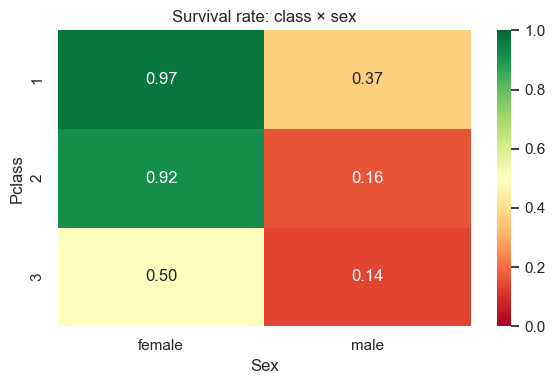

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", ax=ax, vmin=0, vmax=1)
ax.set_title("Survival rate: class × sex")
plt.tight_layout()
plt.savefig("../images/class_sex_interaction.png", dpi=120)
plt.show()

**Finding:** the interaction is not additive. 3rd-class women (50%) survived at roughly the same
rate as 1st-class men (37%) — sex dominates within any given class, but class still moves the needle
by 20-40 points inside each sex. A model that only sees `Sex` or only sees `Pclass` misses this
compounding effect; an interaction term (or a tree-based model that finds it automatically) matters
for Task 3.

## 5. Continuous variables vs. survival

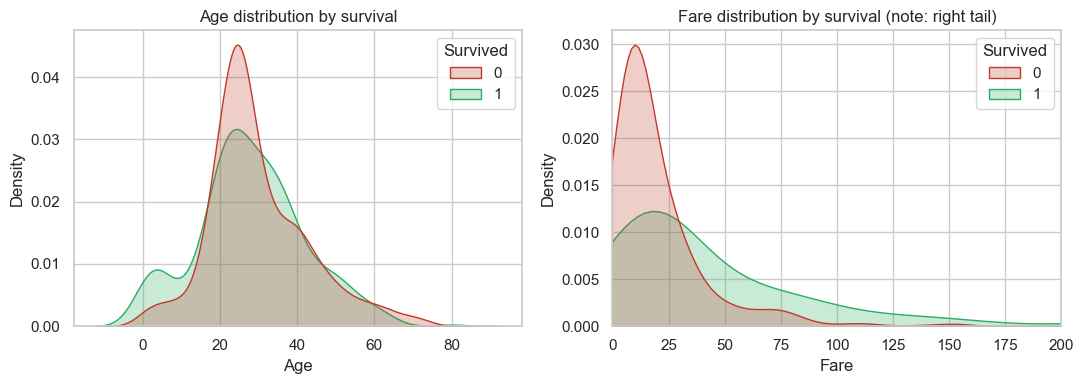

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.kdeplot(data=df, x="Age", hue="Survived", fill=True, common_norm=False, ax=axes[0], palette=["#c0392b","#27ae60"])
axes[0].set_title("Age distribution by survival")
sns.kdeplot(data=df, x="Fare", hue="Survived", fill=True, common_norm=False, ax=axes[1], palette=["#c0392b","#27ae60"])
axes[1].set_title("Fare distribution by survival (note: right tail)")
axes[1].set_xlim(0, 200)
plt.tight_layout()
plt.savefig("../images/continuous_vs_survival.png", dpi=120)
plt.show()

**Finding:** `Age` distributions between survivors and non-survivors overlap heavily — age alone is
a weak signal except at the extremes (children). `Fare` separates much more cleanly: survivors skew
toward higher fares, which is really `Pclass` showing up again (fare and class are highly correlated).

## 6. Correlation structure (numeric features only)

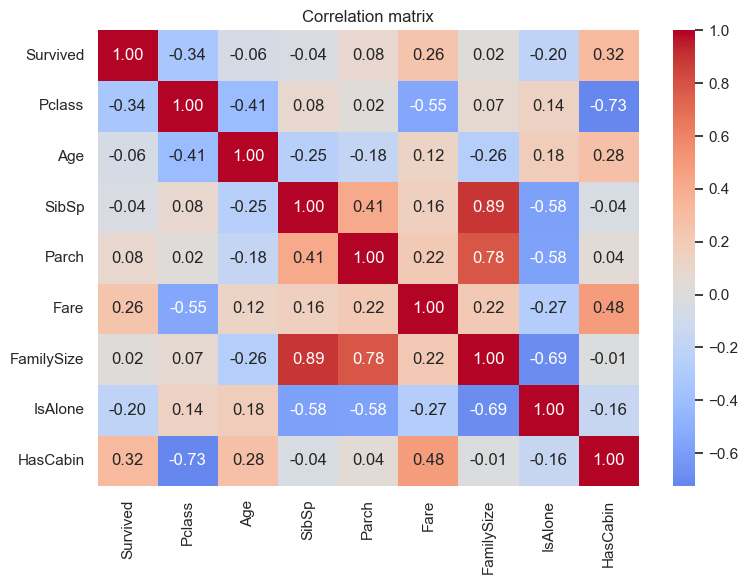

In [12]:
num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "IsAlone", "HasCabin"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax, center=0)
ax.set_title("Correlation matrix")
plt.tight_layout()
plt.savefig("../images/full_correlation_heatmap.png", dpi=120)
plt.show()

In [13]:
print("Fare vs Pclass correlation:", df["Fare"].corr(df["Pclass"]))
print("HasCabin vs Pclass correlation:", df["HasCabin"].corr(df["Pclass"]))

Fare vs Pclass correlation: -0.5494996199439082
HasCabin vs Pclass correlation: -0.7255412418289563


**Finding:** `Fare` and `Pclass` are strongly (negatively) correlated (~-0.55), and `HasCabin` and
`Pclass` too (~-0.73) — cabin records mostly survive for 1st class passengers. These three variables
are largely telling the same story from different angles, which matters for Task 3: feeding all three
into a linear model risks redundant, unstable coefficients; a regularized or tree-based model handles
that better than plain OLS-style coefficients would.

## 7. Statistical checks (not just eyeballing the charts)

In [14]:
# Chi-square: Sex vs Survived
ct = pd.crosstab(df["Sex"], df["Survived"])
chi2, p, dof, exp = stats.chi2_contingency(ct)
print(f"Sex vs Survived: chi2={chi2:.1f}, p={p:.2e}")

# Chi-square: Pclass vs Survived
ct2 = pd.crosstab(df["Pclass"], df["Survived"])
chi2b, pb, dofb, expb = stats.chi2_contingency(ct2)
print(f"Pclass vs Survived: chi2={chi2b:.1f}, p={pb:.2e}")

# t-test: Fare, survivors vs non-survivors
fare_surv = df.loc[df["Survived"]==1, "Fare"]
fare_died = df.loc[df["Survived"]==0, "Fare"]
t, pt = stats.ttest_ind(fare_surv, fare_died, equal_var=False)
print(f"Fare t-test (survived vs died): t={t:.2f}, p={pt:.2e}")

Sex vs Survived: chi2=260.7, p=1.20e-58
Pclass vs Survived: chi2=102.9, p=4.55e-23
Fare t-test (survived vs died): t=6.84, p=2.70e-11


**Reading these:** all three come back at p << 0.05 — `Sex`, `Pclass`, and `Fare` each have a
statistically significant relationship with survival, not just a visually suggestive one. That's
expected given the effect sizes above, but worth confirming rather than assuming the chart is enough.

## 8. Honest Take

- `Sex` and `Pclass` are the backbone of this dataset — everything else (`Fare`, `HasCabin`, `Title`)
  mostly restates one or both of them from a different angle. That's not a flaw in the analysis, it's
  what the data actually is.
- The class × sex interaction is the most useful single finding here — it's the clearest case where a
  model needs to capture a compounding effect, not just two independent main effects.
- `FamilySize`'s non-monotonic relationship (small families > alone or large families) is a genuine
  pattern worth keeping as an engineered feature, not just `SibSp`/`Parch` separately.
- `Fare`/`Pclass`/`HasCabin` multicollinearity is flagged now so Task 3 doesn't quietly overfit on
  three correlated proxies for the same thing.
- Nothing here required inventing structure that wasn't there — the strong relationships are strong,
  and the weak ones (`Age` alone, `Embarked`) are reported as weak rather than dressed up.

In [15]:
from pathlib import Path

Path("../output").mkdir(parents=True, exist_ok=True)

df.to_csv("../output/titanic_eda_features.csv", index=False)
df.shape

(891, 17)